In [45]:
!pip -q install langchain-groq
!pip -q install langgraph
!pip -q install prophet
!pip -q install pmdarima
!pip -q install rich
!pip -q install python-dotenv

In [46]:
# =========================================================
# COMPLETE AUTONOMOUS MULTI-AGENT PIPELINE
# PREPROCESSING → DEBUGGING → MODEL SELECTION
# → HYPERPARAMETER TUNING → FORECASTING
# =========================================================

# -------------------------------
# Standard Libraries
# -------------------------------
import os
import io
import sys
import warnings
import logging
import traceback

from math import sqrt
from typing import TypedDict, List, Dict, Optional

# -------------------------------
# Environment Variables
# -------------------------------
from google.colab import userdata
from dotenv import load_dotenv

# -------------------------------
# Data Processing
# -------------------------------
import pandas as pd
import numpy as np

# -------------------------------
# Machine Learning
# -------------------------------
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import ParameterGrid

# -------------------------------
# Time Series Models
# -------------------------------
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from pmdarima import auto_arima

# -------------------------------
# Groq LLM
# -------------------------------
from langchain_groq import ChatGroq

# -------------------------------
# LangGraph
# -------------------------------
from langgraph.graph import StateGraph, END

# -------------------------------
# Rich Console
# -------------------------------
from rich.console import Console
from rich.panel import Panel
from rich.syntax import Syntax
from rich.table import Table
from rich import box

# =========================================================
# INITIALIZATION
# =========================================================

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.ERROR)

console = Console()

# =========================================================
# LOAD GROQ API KEY
# =========================================================

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=GROQ_API_KEY
)

In [47]:
# =========================================================
# CONFIGURATION
# =========================================================

from google.colab import userdata

# Groq API Key
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

# =========================================================
# CONFIGURATION
# =========================================================

DATASET_PATH = "dataset.csv"
PREPROCESSED_DATASET = "Final_Dataset.csv"

TARGET_COLUMN = "quantity_sold"
FORECAST_DAYS = 7

# LLM Configuration
MODEL_NAME = "llama-3.3-70b-versatile"
TEMPERATURE = 0

# =========================================================
# INITIALIZE GROQ LLM
# =========================================================

llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model=MODEL_NAME,
    temperature=TEMPERATURE
)

# =========================================================
# LOGGING
# =========================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore")

console = Console()

logging is a Python module used to record what your program is doing while it runs. It helps you monitor progress, debug problems, and keep a record of important events.

Instead of using only print(), logging lets you classify messages by importance.

========

| Level      | Purpose                                     | Example                          |
| ---------- | ------------------------------------------- | -------------------------------- |
| `DEBUG`    | Detailed information for debugging          | Variable values, loop iterations |
| `INFO`     | General program progress                    | "Dataset loaded successfully"    |
| `WARNING`  | Something unexpected, but program continues | "Missing values found"           |
| `ERROR`    | An error occurred                           | "Failed to load dataset"         |
| `CRITICAL` | Serious error; program may stop             | "Model training failed"          |


In [48]:
# =========================================================
# LOAD DATASET
# =========================================================

try:
    df = pd.read_csv(DATASET_PATH)

    console.print(
        "\n[bold green]Dataset Loaded Successfully[/bold green]\n"
    )

    logger.info(f"Dataset loaded successfully.")
    logger.info(f"Dataset Shape: {df.shape}")

except Exception as e:
    console.print(
        f"[bold red]Error Loading Dataset:[/bold red] {e}"
    )
    logger.error(f"Error loading dataset: {e}")
    raise

# =========================================================
# DISPLAY DATASET PREVIEW
# =========================================================

preview_table = Table(
    title="Dataset Preview",
    box=box.DOUBLE_EDGE,
    show_lines=True
)

for col in df.columns:
    preview_table.add_column(col, style="cyan")

for _, row in df.head().iterrows():
    preview_table.add_row(*[str(value) for value in row])

console.print(preview_table)

Dataset Loaded Successfully

                        Dataset Preview                        
╔════════════╤═════════╤══════════╤═══════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold │ inventory ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-01 │ SKU_101 │ Chennai  │ 52.0          │ 120       ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-02 │ SKU_101 │ Chennai  │ 49.0          │ 115       ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-03 │ SKU_101 │ Chennai  │ nan           │ 110       ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-04 │ SKU_101 │ Chennai  │ 55.0          │ 105       ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-05 │ SKU_101 │ Chennai  │ 60.0          │ 100       ║
╚════════════╧═════════╧══════════╧═══════════════╧═══════════╝

In [49]:
# =========================================================
# PREPROCESSING TASKS
# =========================================================

PREPROCESSING_TASKS = [

    "Display dataset summary",

    "Print number of rows, columns and column names",

    "Identify numerical and categorical columns",

    "Handle missing values",

    "Handle outliers using IQR for numeric columns only",

    "Find duplicate rows"
]


In [50]:
# =========================================================
# STATE
# =========================================================

class TradingState(TypedDict):

    # preprocessing
    df: pd.DataFrame

    tasks: List[str]

    task_index: int

    current_task: str

    generated_code: str

    preprocessing_output: str

    preprocessing_error: Optional[str]

    retry_count: int

    max_retries: int

    debug_history: List[str]

    last_error: str

    # forecasting
    models: List[str]

    results: List[Dict]

    best_model: str

    tuning_method: str

    best_params: Dict

    forecast_df: pd.DataFrame


In [51]:
# =========================================================
# PREPROCESSING EXECUTOR
# =========================================================

def preprocessing_executor(state):

    code = state["generated_code"]

    dataframe = state["df"].copy()

    execution_scope = {
        "__builtins__": __builtins__,
        "pd": pd,
        "np": np,
        "df": dataframe
    }

    buffer = io.StringIO()

    try:

        original_stdout = sys.stdout
        sys.stdout = buffer

        # Execute generated code
        exec(code, execution_scope, execution_scope)

        sys.stdout = original_stdout

        updated_df = execution_scope.get("df", dataframe)

        output = buffer.getvalue()

        console.print(
            Panel(
                output if output else "Execution Completed Successfully",
                title="Execution Output",
                style="bold green"
            )
        )

        return {
            "df": updated_df,
            "preprocessing_output": output,
            "preprocessing_error": None,
            "last_error": ""
        }

    except Exception:

        sys.stdout = original_stdout

        error_message = traceback.format_exc()

        console.print(
            Panel(
                error_message,
                title="Execution Failed",
                style="bold red"
            )
        )

        return {
            "df": dataframe,
            "preprocessing_output": "",
            "preprocessing_error": error_message,
            "last_error": error_message
        }

In [52]:

# =========================================================
# DEBUGGER AGENT
# =========================================================

def debugger_agent(state):

    console.print(

        "\n[bold red]"
        "DEBUGGER AGENT ACTIVATED"
        "[/bold red]"
    )

    task = state["current_task"]

    original_code = state["generated_code"]

    error_message = state["last_error"]

    debug_prompt = f"""
You are an expert Python debugging engineer.

Task:
{task}

Original Code:
{original_code}

Execution Error:
{error_message}

Rules:
1. Fix the error
2. Preserve original logic
3. Dataframe name must remain df
4. Use pandas and numpy only
5. Return ONLY executable Python code
6. Do not explain anything
7. Ensure numeric-only operations are handled correctly
"""

    response = llm.invoke(debug_prompt)

    fixed_code = response.content.strip()

    fixed_code = fixed_code.replace(
        "```python",
        ""
    )

    fixed_code = fixed_code.replace(
        "```",
        ""
    )

    console.print(

        "\n[bold yellow]"
        "FIXED CODE GENERATED"
        "[/bold yellow]\n"
    )

    syntax = Syntax(

        fixed_code,

        "python",

        theme="monokai"
    )

    console.print(syntax)

    debug_history = state["debug_history"]

    debug_history.append(error_message)

    return {

        "generated_code": fixed_code,

        "retry_count":
        state["retry_count"] + 1,

        "debug_history": debug_history
    }


In [53]:
# =========================================================
# EXECUTION ROUTER
# =========================================================

def execution_router(state):

    if state["preprocessing_error"] is None:

        return "preprocessing_checker"

    if state["retry_count"] >= state["max_retries"]:

        return END

    return "debugger_agent"


# =========================================================
# PREPROCESSING CHECKER
# =========================================================

def preprocessing_checker(state):

    console.print(

        "\n[bold green]"
        "Preprocessing Completed"
        "[/bold green]"
    )

    return {}


# =========================================================
# NEXT TASK
# =========================================================

def next_task_agent(state):

    return {

        "task_index":
        state["task_index"] + 1,

        "retry_count": 0
    }


# =========================================================
# PREPROCESSING ROUTER
# =========================================================

def preprocessing_router(state):

    next_index = state["task_index"] + 1

    if next_index >= len(state["tasks"]):

        return "forecast_planner"

    return "preprocessing_planner"


In [54]:

# =========================================================
# FORECAST PLANNER
# =========================================================

def forecast_planner(state):

    console.print(

        "\n[bold magenta]"
        "MODEL SELECTION PHASE"
        "[/bold magenta]"
    )

    models = [

        "ARIMA",

        "SARIMAX",

        "Prophet"
    ]

    if len(state["df"]) > 500:

        models.append("LSTM")

    console.print(

        f"Models Selected → {models}"
    )

    return {

        "models": models
    }


# =========================================================
# PREPARE FORECAST DATA
# =========================================================

def prepare_forecasting_data(df):

    df["date"] = pd.to_datetime(
        df["date"]
    )

    df = df.sort_values("date")

    df.set_index(
        "date",
        inplace=True
    )

    df = df.asfreq("D")

    df["lag1"] = df[
        TARGET_COLUMN
    ].shift(1)

    df["lag7"] = df[
        TARGET_COLUMN
    ].shift(7)

    df = df.dropna()

    split_index = int(
        len(df) * 0.8
    )

    train = df.iloc[:split_index]

    test = df.iloc[split_index:]

    y_train = train[TARGET_COLUMN]

    y_test = test[TARGET_COLUMN]

    return df, y_train, y_test


# =========================================================
# METRICS
# =========================================================

def evaluate(actual, pred):

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = sqrt(

        mean_squared_error(
            actual,
            pred
        )
    )

    mape = np.mean(

        np.abs(
            (actual - pred)
            / (actual + 1e-10)
        )
    ) * 100

    return {

        "MAE": round(mae, 3),

        "RMSE": round(rmse, 3),

        "MAPE": round(mape, 3)
    }


# =========================================================
# FORECAST EXECUTOR
# =========================================================

def forecast_executor(state):

    console.print(

        "\n[bold yellow]"
        "Running Forecast Models"
        "[/bold yellow]"
    )

    results = []

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    for model_name in state["models"]:

        try:

            if model_name == "ARIMA":

                model = ARIMA(
                    y_train,
                    order=(1,1,1)
                )

                fit = model.fit()

                pred = fit.forecast(
                    len(y_test)
                )


            elif model_name == "SARIMAX":

                model = SARIMAX(
                    y_train,
                    order=(1,1,1)
                )

                fit = model.fit()

                pred = fit.forecast(
                    len(y_test)
                )


            elif model_name == "Prophet":

                prophet_df = (
                    processed_df
                    .reset_index()[[
                        "date",
                        TARGET_COLUMN
                    ]]
                )

                prophet_df.columns = [
                    "ds",
                    "y"
                ]

                split = int(
                    len(prophet_df) * 0.8
                )

                train_p = prophet_df.iloc[:split]

                test_p = prophet_df.iloc[split:]

                model = Prophet()

                model.fit(train_p)

                future = model.make_future_dataframe(
                    periods=len(test_p)
                )

                forecast = model.predict(
                    future
                )

                pred = forecast[
                    "yhat"
                ].iloc[-len(test_p):]

                metrics = evaluate(
                    test_p["y"],
                    pred
                )

                results.append({

                    "Model": model_name,

                    **metrics
                })

                continue

            metrics = evaluate(
                y_test,
                pred
            )

            results.append({

                "Model": model_name,

                **metrics
            })

            console.print(

                f"[green]"
                f"{model_name} Completed"
                f"[/green]"
            )

        except Exception as e:

            logger.exception(e)

    return {

        "results": results
    }


# =========================================================
# MODEL CHECKER
# =========================================================

def model_checker(state):

    results_df = pd.DataFrame(
        state["results"]
    )

    table = Table(

        title="Model Results",

        box=box.DOUBLE_EDGE
    )

    for col in results_df.columns:

        table.add_column(col)

    for _, row in results_df.iterrows():

        table.add_row(
            *[str(i) for i in row]
        )

    console.print(table)

    return {}


# =========================================================
# BEST MODEL SELECTOR
# =========================================================

def best_model_selector(state):

    results_df = pd.DataFrame(
        state["results"]
    )

    best_row = results_df.sort_values(
        "RMSE"
    ).iloc[0]

    best_model = best_row["Model"]

    console.print(

        f"\n[bold green]"
        f"Best Model → {best_model}"
        f"[/bold green]"
    )

    return {

        "best_model": best_model
    }


# =========================================================
# TUNING AGENT
# =========================================================

def tuning_agent(state):

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    param_grid = {

        "p": [0,1,2],

        "d": [0,1],

        "q": [0,1,2]
    }

    best_score = np.inf

    best_params = None

    for params in ParameterGrid(param_grid):

        try:

            model = ARIMA(

                y_train,

                order=(
                    params["p"],
                    params["d"],
                    params["q"]
                )
            ).fit()

            pred = model.forecast(
                len(y_test)
            )

            rmse = evaluate(
                y_test,
                pred
            )["RMSE"]

            if rmse < best_score:

                best_score = rmse

                best_params = params

        except:
            pass

    auto_model = auto_arima(

        y_train,

        seasonal=False
    )

    auto_pred = auto_model.predict(
        n_periods=len(y_test)
    )

    auto_rmse = evaluate(
        y_test,
        auto_pred
    )["RMSE"]

    scores = {

        "GridSearch": best_score,

        "AutoARIMA": auto_rmse
    }

    best_method = min(
        scores,
        key=scores.get
    )

    console.print(

        f"\nBest Tuning Method → "
        f"{best_method}"
    )

    return {

        "tuning_method": best_method,

        "best_params": best_params
    }


# =========================================================
# FORECASTING AGENT
# =========================================================

def forecasting_agent(state):

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    y_full = processed_df[
        TARGET_COLUMN
    ]

    best_model = state["best_model"]

    if best_model == "ARIMA":

        model = ARIMA(
            y_full,
            order=(1,1,1)
        )

        fit = model.fit()

        forecast = fit.forecast(
            steps=FORECAST_DAYS
        )


    elif best_model == "SARIMAX":

        model = SARIMAX(
            y_full,
            order=(1,1,1)
        )

        fit = model.fit()

        forecast = fit.forecast(
            steps=FORECAST_DAYS
        )


    elif best_model == "Prophet":

        prophet_df = (
            processed_df
            .reset_index()[[
                "date",
                TARGET_COLUMN
            ]]
        )

        prophet_df.columns = [
            "ds",
            "y"
        ]

        model = Prophet()

        model.fit(prophet_df)

        future = model.make_future_dataframe(
            periods=FORECAST_DAYS
        )

        forecast_result = model.predict(
            future
        )

        forecast = forecast_result[
            "yhat"
        ].tail(
            FORECAST_DAYS
        ).values


    future_dates = pd.date_range(

        start=processed_df.index[-1]
        + pd.Timedelta(days=1),

        periods=FORECAST_DAYS
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Forecast": forecast
    })

    console.print(

        Panel(

            str(forecast_df),

            title="Forecast Output"
        )
    )

    return {

        "forecast_df": forecast_df
    }



In [55]:
# =========================================================
# BUILD GRAPH
# =========================================================

builder = StateGraph(TradingState)


# =========================================================
# PREPROCESSING NODES
# =========================================================

builder.add_node(
    "preprocessing_planner",
    preprocessing_planner
)

builder.add_node(
    "preprocessing_coder",
    preprocessing_coder
)

builder.add_node(
    "preprocessing_executor",
    preprocessing_executor
)

builder.add_node(
    "debugger_agent",
    debugger_agent
)

builder.add_node(
    "preprocessing_checker",
    preprocessing_checker
)

builder.add_node(
    "next_task",
    next_task_agent
)


# =========================================================
# FORECASTING NODES
# =========================================================

builder.add_node(
    "forecast_planner",
    forecast_planner
)

builder.add_node(
    "forecast_executor",
    forecast_executor
)

builder.add_node(
    "model_checker",
    model_checker
)

builder.add_node(
    "best_model_selector",
    best_model_selector
)

builder.add_node(
    "tuning_agent",
    tuning_agent
)

builder.add_node(
    "forecasting_agent",
    forecasting_agent
)


# =========================================================
# ENTRY POINT
# =========================================================

builder.set_entry_point(
    "preprocessing_planner"
)


# =========================================================
# PREPROCESSING FLOW
# =========================================================

builder.add_edge(
    "preprocessing_planner",
    "preprocessing_coder"
)

builder.add_edge(
    "preprocessing_coder",
    "preprocessing_executor"
)


# =========================================================
# EXECUTION ROUTING
# =========================================================

builder.add_conditional_edges(

    "preprocessing_executor",

    execution_router,

    {

        "preprocessing_checker":
        "preprocessing_checker",

        "debugger_agent":
        "debugger_agent",

        END: END
    }
)


# =========================================================
# DEBUG LOOP
# =========================================================

builder.add_edge(
    "debugger_agent",
    "preprocessing_executor"
)


# =========================================================
# CONTINUE PREPROCESSING
# =========================================================

builder.add_edge(
    "preprocessing_checker",
    "next_task"
)

builder.add_conditional_edges(

    "next_task",

    preprocessing_router,

    {

        "preprocessing_planner":
        "preprocessing_planner",

        "forecast_planner":
        "forecast_planner"
    }
)



In [56]:
# =========================================================
# FORECAST FLOW
# =========================================================

builder.add_edge(
    "forecast_planner",
    "forecast_executor"
)

builder.add_edge(
    "forecast_executor",
    "model_checker"
)

builder.add_edge(
    "model_checker",
    "best_model_selector"
)

builder.add_edge(
    "best_model_selector",
    "tuning_agent"
)

builder.add_edge(
    "tuning_agent",
    "forecasting_agent"
)

builder.add_edge(
    "forecasting_agent",
    END
)


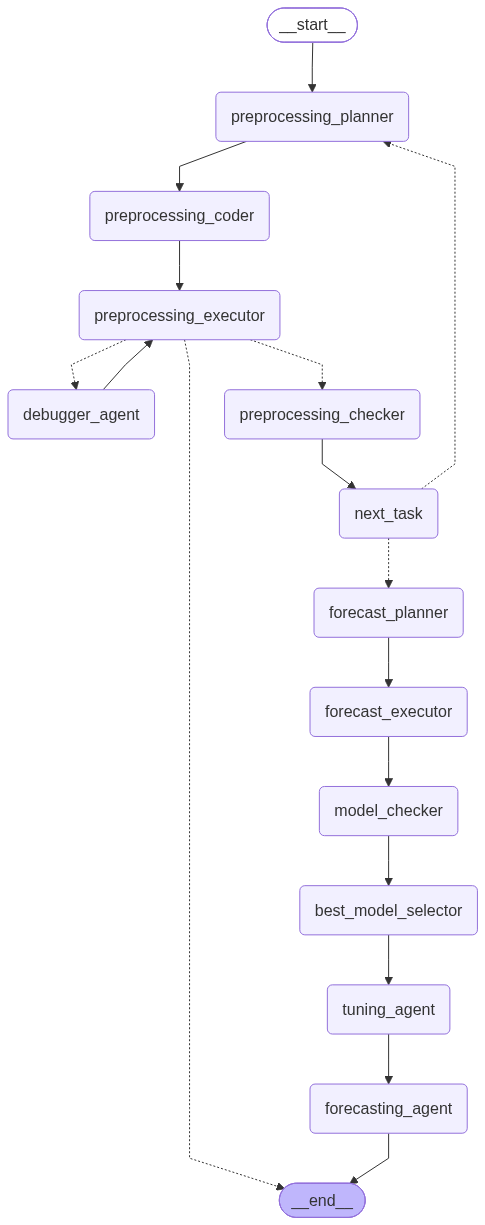

In [57]:
# =========================================================
# COMPILE GRAPH
# =========================================================

graph = builder.compile()


# =========================================================
# VISUALIZE GRAPH
# =========================================================

from IPython.display import (
    Image,
    display
)

graph_png = graph.get_graph().draw_mermaid_png()

display(Image(graph_png))

#print(
 #   graph.get_graph().draw_ascii()
#)


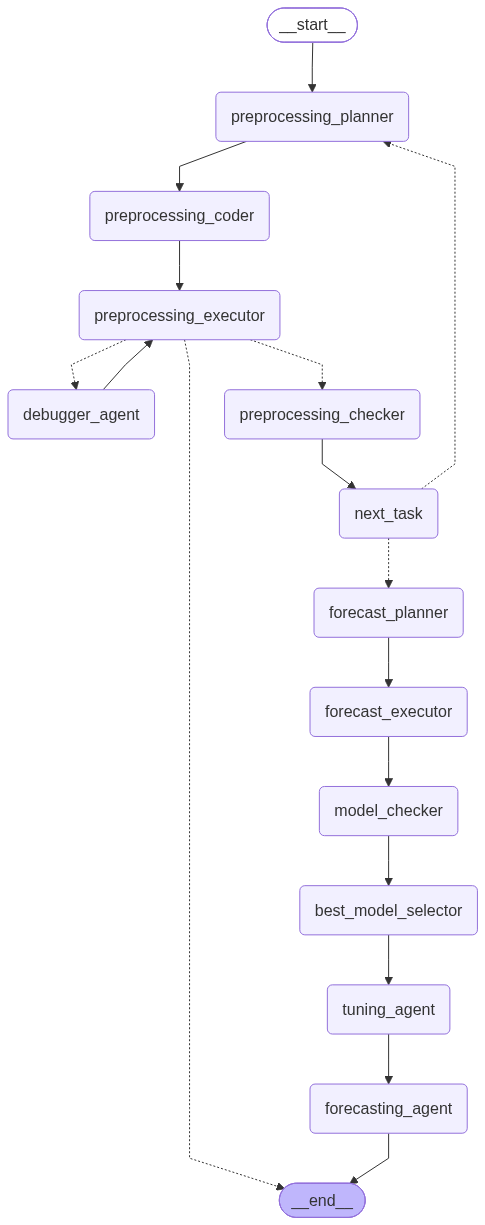

In [58]:
# Save image
with open("langgraph.png", "wb") as f:
    f.write(graph_png)

print("Graph image saved successfully!")

# Display image
display(Image(graph_png))

In [59]:
# =========================================================
# RUN GRAPH
# =========================================================

initial_state = {
    "df": df,
    "tasks": PREPROCESSING_TASKS,
    "task_index": 0,
    "current_task": "",
    "generated_code": "",
    "preprocessing_output": "",
    "preprocessing_error": None,
    "retry_count": 0,
    "max_retries": 3,
    "debug_history": [],
    "last_error": "",
    "models": [],
    "results": [],
    "best_model": "",
    "tuning_method": "",
    "best_params": {},
    "forecast_df": None
}

try:
    final_state = graph.invoke(
        initial_state,
        config={"recursion_limit": 100}
    )

except Exception as e:
    console.print(f"[bold red]Pipeline Failed:[/bold red] {e}")
    raise

# =========================================================
# SAVE PREPROCESSED DATA
# =========================================================

if final_state.get("df") is not None:

    final_state["df"].to_csv(
        PREPROCESSED_DATASET,
        index=False
    )

    console.print(
        f"[green]✓ Preprocessed dataset saved as '{PREPROCESSED_DATASET}'[/green]"
    )

else:
    console.print(
        "[red]Preprocessed dataset is not available.[/red]"
    )

# =========================================================
# SAVE FORECAST
# =========================================================

forecast_df = final_state.get("forecast_df")

if forecast_df is not None:

    forecast_df.to_csv(
        "Forecast_Output.csv",
        index=False
    )

    console.print(
        "[green]✓ Forecast saved as 'Forecast_Output.csv'[/green]"
    )

else:
    console.print(
        "[yellow]Forecast was not generated. Check previous agent errors.[/yellow]"
    )

# =========================================================
# PIPELINE COMPLETED
# =========================================================

console.print(
    "\n[bold green]AUTONOMOUS MULTI-AGENT PIPELINE COMPLETED[/bold green]"
)

PREPROCESSING TASK 1

Display dataset summary

Generated Code

import pandas as pd                                                                                                
import numpy as np                                                                                                 
                                                                                                                   
# Display dataset summary                                                                                          
print("Dataset Shape:", df.shape)                                                                                  
print("Dataset Columns:", df.columns)                                                                              
print("Dataset Info:\n", df.info())                                                                                
print("Dataset Description:\n", df.describe())                                                                     
print("Dataset Head:\n", df.head())                                                                                
print("Dataset Tail:\n", df.tail())                                                                                

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│ Dataset Shape: (30, 5)                                                                                          │
│ Dataset Columns: Index(['date', 'sku', 'location', 'quantity_sold', 'inventory'], dtype='object')               │
│ <class 'pandas.core.frame.DataFrame'>                                                                           │
│ RangeIndex: 30 entries, 0 to 29                                                                                 │
│ Data columns (total 5 columns):                                                                                 │
│  #   Column         Non-Null Count  Dtype                                                                       │
│ ---  ------         --------------  -----                                                                       │
│  0   date           30 non-null     object                                                                      │
│  1   sku            30 non-null     object                                                                      │
│  2   location       30 non-null     object                                                                      │
│  3   quantity_sold  28 non-null     float64                                                                     │
│  4   inventory      30 non-null     int64                                                                       │
│ dtypes: float64(1), int64(1), object(3)                                                                         │
│ memory usage: 1.3+ KB                                                                                           │
│ Dataset Info:                                                                                                   │
│  None                                                                                                           │
│ Dataset Description:                                                                                            │
│         quantity_sold   inventory                                                                               │
│ count      28.000000   30.000000                                                                                │
│ mean       81.964286   51.500000                                                                                │
│ std        95.572537   38.799884                                                                                │
│ min        -5.000000    0.000000                                                                                │
│ 25%        55.750000   16.250000                                                                                │
│ 50%        62.500000   47.500000                                                                                │
│ 75%        69.250000   83.750000                                                                                │
│ max       500.000000  120.000000                                                                                │
│ Dataset Head:                                                                                                   │
│           date      sku location  quantity_sold  inventory                                                      │
│ 0  2024-01-01  SKU_101  Chennai           52.0        120                                                       │
│ 1  2024-01-02  SKU_101  Chennai           49.0        115                                                       │
│ 2  2024-01-03  SKU_101  Chennai            NaN        110                                                       │
│ 3  2024-01-04  SKU_101  Chennai           55.0        105                                                       │
│ 4  2024-01-05  SKU_101  Chennai           60.0        100                                                       │
│ Dataset Tail:                                         

...

Best Tuning Method → GridSearch

╭──────────────────────────────────────────────── Forecast Output ────────────────────────────────────────────────╮
│                  Date   Forecast                                                                                │
│ 2024-01-31 2024-01-31  71.278665                                                                                │
│ 2024-02-01 2024-02-01  70.935324                                                                                │
│ 2024-02-02 2024-02-02  70.892006                                                                                │
│ 2024-02-03 2024-02-03  70.886540                                                                                │
│ 2024-02-04 2024-02-04  70.885851                                                                                │
│ 2024-02-05 2024-02-05  70.885764                                                                                │
│ 2024-02-06 2024-02-06  70.885753                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✓ Preprocessed dataset saved as 'Final_Dataset.csv'

✓ Forecast saved as 'Forecast_Output.csv'

AUTONOMOUS MULTI-AGENT PIPELINE COMPLETED